# Twitter sentiment analysis

*   uplaoded the dataset from kaggle

*    For the sake of simplicity, we say a tweet contains hate speech if it has a racist or sexist sentiment associated with it. So, the task is to classify racist or sexist tweets from other tweets. Formally, given a training sample of tweets and labels, where label '1' denotes the tweet is racist/sexist and label '0' denotes the tweet is not racist/sexist, your objective is to predict the labels on the test dataset




In [4]:
# Upload CSV
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Read dataset
df = pd.read_csv(next(iter(uploaded)))

# Preview
df.head()

Saving train.csv to train.csv


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


step 2: cleaning the data

In [5]:
!pip install nltk

import re
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtag symbol but keep word
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [7]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [8]:
df['clean_text'] = df['tweet'].apply(clean_tweet)

df[['tweet', 'clean_text']].head()

,tweet,clean_text
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit cant use cause dont offer w...
2,bihday your majesty,bihday majesty
3,#model i love u take with u all the time in ...,model love u take u time urð ðððð ððð
4,factsguide: society now #motivation,factsguide society motivation


getting the shape and information about data


In [9]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("Shape after cleaning:", df.shape)


Shape after cleaning: (31962, 4)


In [10]:
label_counts = df['label'].value_counts()

print(f"Negative Tweets: {label_counts.get(1, 0)}")
print(f"Positive Tweets: {label_counts.get(0, 0)}")

Negative Tweets: 2242
Positive Tweets: 29720


step 3: Dataset Split:

Training: 70%

Validation: 15%

Testing: 15%

In [11]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 22373
Validation: 4794
Test: 4795


In [12]:
print("Train Distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation Distribution:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTest Distribution:")
print(y_test.value_counts(normalize=True) * 100)

Train Distribution:
label
0    92.987083
1     7.012917
Name: proportion, dtype: float64

Validation Distribution:
label
0    92.991239
1     7.008761
Name: proportion, dtype: float64

Test Distribution:
label
0    92.971846
1     7.028154
Name: proportion, dtype: float64


step 4: covert the words into vector using IF-IDF

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

step 5: use logistic regression to train the data

In [14]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

check on validation set

In [15]:
y_val_pred = lr_model.predict(X_val_tfidf)

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Validation Accuracy: 0.919482686691698

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96      4458
           1       0.46      0.76      0.57       336

    accuracy                           0.92      4794
   macro avg       0.72      0.85      0.76      4794
weighted avg       0.94      0.92      0.93      4794


Confusion Matrix:
[[4151  307]
 [  79  257]]


In [17]:
print(classification_report(
    y_val,
    y_val_pred,
    target_names=[
        "No Racism/Sexism",
        "Racism/Sexism"
    ]
))

                  precision    recall  f1-score   support

No Racism/Sexism       0.98      0.93      0.96      4458
   Racism/Sexism       0.46      0.76      0.57       336

        accuracy                           0.92      4794
       macro avg       0.72      0.85      0.76      4794
    weighted avg       0.94      0.92      0.93      4794



In [18]:
import pandas as pd
import numpy as np

feature_names = tfidf.get_feature_names_out()

coefficients = lr_model.coef_[0]

top_positive = np.argsort(coefficients)[-20:]
top_negative = np.argsort(coefficients)[:20]

print("Words indicating Racism/Sexism:")
for idx in reversed(top_positive):
    print(feature_names[idx])

print("\nWords indicating No Racism/Sexism:")
for idx in top_negative:
    print(feature_names[idx])

Words indicating Racism/Sexism:
allahsoil
white
racist
racism
black
trump
woman
bigot
equality
blm
misogyny
comment
kkk
latest
obama
jew
blacklivesmatter
maga
liberal
race

Words indicating No Racism/Sexism:
day
bihday
happy
orlando
life
love
healthy
smile
tomorrow
weekend
friday
week
happiness
thankful
amazing
ready
tonight
summer
friend
beautiful


Multinomial Naive Bayes

In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_val_pred_nb = nb_model.predict(X_val_tfidf)

print(classification_report(
    y_val,
    y_val_pred_nb,
    target_names=[
        "No Racism/Sexism",
        "Racism/Sexism"
    ]
))

                  precision    recall  f1-score   support

No Racism/Sexism       0.95      1.00      0.97      4458
   Racism/Sexism       0.94      0.30      0.45       336

        accuracy                           0.95      4794
       macro avg       0.95      0.65      0.71      4794
    weighted avg       0.95      0.95      0.94      4794



Linear SVM

In [20]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

y_val_pred_svm = svm_model.predict(X_val_tfidf)

print(classification_report(
    y_val,
    y_val_pred_svm,
    target_names=[
        "No Racism/Sexism",
        "Racism/Sexism"
    ]
))

                  precision    recall  f1-score   support

No Racism/Sexism       0.98      0.94      0.96      4458
   Racism/Sexism       0.47      0.71      0.56       336

        accuracy                           0.92      4794
       macro avg       0.72      0.82      0.76      4794
    weighted avg       0.94      0.92      0.93      4794



best f1 score is in Logistc regression so use it on test set

In [21]:
y_test_pred = lr_model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=[
        "No Racism/Sexism",
        "Racism/Sexism"
    ]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.9234619395203337

Classification Report:
                  precision    recall  f1-score   support

No Racism/Sexism       0.98      0.93      0.96      4458
   Racism/Sexism       0.47      0.78      0.59       337

        accuracy                           0.92      4795
       macro avg       0.73      0.86      0.77      4795
    weighted avg       0.95      0.92      0.93      4795


Confusion Matrix:
[[4165  293]
 [  74  263]]


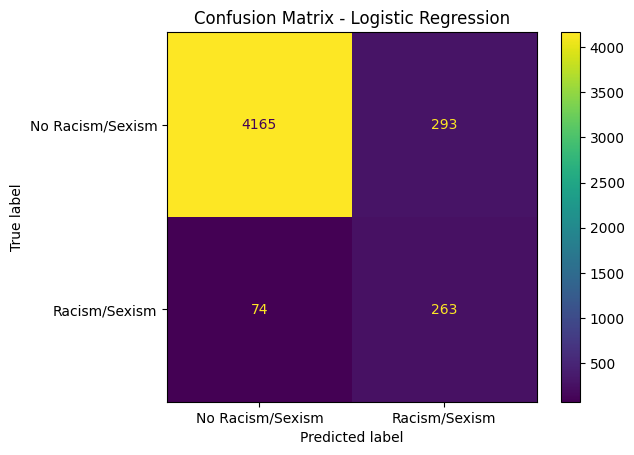

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=[
        "No Racism/Sexism",
        "Racism/Sexism"
    ]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

step 6: analyze mistakes

In [23]:
y_val_pred = lr_model.predict(X_val_tfidf)

In [24]:
import pandas as pd

results = pd.DataFrame({
    'tweet': X_test,
    'actual': y_test,
    'predicted': y_test_pred
})

results.head()

,tweet,actual,predicted
20148,wife beater try act like badass pander vote,0,1
31020,godz green eah u guy release centralintelligen...,0,0
11154,love uð ð ë³ê²ììì¼ìííð bogumdayð dayð sdayð,0,0
53,let scumbaggery begin,0,0
26499,meet semifinalist casfactor show,0,0


In [25]:
errors = results[results['actual'] != results['predicted']]

print("Total Errors:", len(errors))
errors.head(10)

Total Errors: 367


,tweet,actual,predicted
20148,wife beater try act like badass pander vote,0,1
2877,bitch hate dislike stalk dont even know even e...,0,1
16365,trump clinton leading american choose lesser e...,0,1
8007,dare say think amp feel word live keep calm am...,0,1
7148,yeah shell elected right jill stein million wo...,0,1
13741,sad muslim eat ramadaan noshame,0,1
18563,show u ur tax would traffic jam going mexico d...,0,1
27009,agree take bin common sense know persistent on...,0,1
22100,huffington post woman drop fbombs dodgy dave c...,0,1
6789,millennials still prospect woman president via,0,1


In [26]:
false_negatives = results[
    (results['actual'] == 1) &
    (results['predicted'] == 0)
]

print("False Negatives:", len(false_negatives))
false_negatives[['tweet']].head(20)

False Negatives: 74


,tweet
23379,yes apparently qualified job dependent upon et...
21767,lee atwater caught n tape explains southern st...
14866,tyruswong bambi aist thwaed didnt want child c...
31946,omfg im offended im mailbox im proud mailboxpr...
27417,im mixed w native american spanish irish u call ð
12067,far right georgia showing euro value
14965,meet wilmington peacekeeper walk beauty cnv we...
27573,fakenews must feel good
30397,let tell story videogames specifically marvel ...
10319,scary long ago


In [30]:
errors = results[results['actual'] != results['predicted']]

errors.sort_values(
    by='prob_racism_sexism',
    ascending=False
).head(10)

,tweet,actual,predicted,prob_racism_sexism
848,rightly gop hate trump obama,0,1,0.988907
4950,tell version lie hatred vile attack upon black...,0,1,0.987530
27934,slip threat america bigotry misogyny ignorance...,0,1,0.982274
6419,believe miscegenation genocide stop breeding b...,0,1,0.978090
6789,millennials still prospect woman president via,0,1,0.976818
18616,anyone suppos clinton feminist basis care whit...,0,1,0.976065
3879,yapping right idiot trump,0,1,0.975509
28216,everybody hate white crayon,0,1,0.973869
7497,yes republican voter polled believe trump said...,0,1,0.970199
864,think suspend indefininetly racist staff,0,1,0.961772


In [29]:
import joblib

# Save model
joblib.dump(lr_model, 'logistic_regression_model.pkl')

# Save TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [40]:
new_tweet = ["black people should not be allowed to work"]

new_tweet_tfidf = tfidf.transform(new_tweet)

prediction = lr_model.predict(new_tweet_tfidf)

if prediction[0] == 1:
    print("Negative comment")
else:
    print("Positive comment")

Negative comment


In [37]:
new_tweet = ["everyone should not discreminate on basis of color."]

new_tweet_tfidf = tfidf.transform(new_tweet)

prediction = lr_model.predict(new_tweet_tfidf)

if prediction[0] == 1:
    print("Negative comment")
else:
    print("Positive comment")

Positive comment


In [38]:
new_tweet = ["She should be allowed to work anywhere."]

new_tweet_tfidf = tfidf.transform(new_tweet)

prediction = lr_model.predict(new_tweet_tfidf)

if prediction[0] == 1:
    print("Negative comment")
else:
    print("Positive comment")

Positive comment
